#IMPORT LIBRARY

In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv('/content/student_mental_health_burnout.csv')

# menghapus spasi tersembunyi
df.columns = df.columns.str.strip()

# =========================================================
# MENAMPILKAN RAW DATA
# =========================================================
print("Jumlah Data :", df.shape)
print("\nInformasi Dataset")


print("\n5 Data Pertama")
display(df.head())

# =========================================================
# INFORMASI DATASET
# =========================================================

print(df.info())

print("\nNama Kolom Dataset")
print(df.columns.tolist())

print("\nMissing Value")
print(df.isnull().sum())

print("\nStatistik Deskriptif")
display(df.describe(include='all'))

Jumlah Data : (150000, 20)

Informasi Dataset

5 Data Pertama


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
count,150000.000000,150000.000000,150000,150000,150000,150000.000000,150000.000000,150000.000000,150000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000,150000.000000,150000.000000,150000,150000
unique,NaN,NaN,3,6,4,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,3,3
top,NaN,NaN,Other,MBA,1st,NaN,NaN,NaN,High,NaN,NaN,NaN,NaN,NaN,NaN,Good,NaN,NaN,Average,Low
freq,NaN,NaN,50048,25231,37680,NaN,NaN,NaN,50295,NaN,NaN,NaN,NaN,NaN,NaN,50143,NaN,NaN,50138,50265
mean,175000.500000,21.000380,NaN,NaN,NaN,5.507869,6.499361,6.502819,NaN,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,NaN,75.009528,6.997389,NaN,NaN
std,43301.414527,2.581216,NaN,NaN,NaN,2.595592,1.443859,3.178948,NaN,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,NaN,14.409510,1.732180,NaN,NaN
min,100001.000000,17.000000,NaN,NaN,NaN,1.000000,4.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN,50.000000,4.000000,NaN,NaN
25%,137500.750000,19.000000,NaN,NaN,NaN,3.300000,5.200000,3.700000,NaN,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,NaN,62.500000,5.500000,NaN,NaN
50%,175000.500000,21.000000,NaN,NaN,NaN,5.500000,6.500000,6.500000,NaN,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,NaN,75.000000,6.990000,NaN,NaN
75%,212500.250000,23.000000,NaN,NaN,NaN,7.700000,7.700000,9.300000,NaN,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,NaN,87.500000,8.500000,NaN,NaN


#REPROSESSING DATA

In [ ]:
# =========================================================
# PREPROCESSING DATA
# =========================================================

print("\n================ PREPROCESSING DATA ================\n")

# 1. Hapus data duplikat
df = df.drop_duplicates()

# 2. Menangani missing value
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nPreprocessing selesai")
display(df.head())


================ PREPROCESSING DATA ================


Preprocessing selesai


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


#MENAMBAH VARIABEL BARU

In [ ]:
# =========================================================
# MENAMBAHKAN VARIABEL BARU
# =========================================================

# agar hasil random tetap sama
np.random.seed(42)

# =========================================================
# CODING HOURS PER DAY
# =========================================================

df['coding_hours_per_day'] = np.random.uniform(
    1,
    10,
    size=len(df)
)

# =========================================================
# ASSIGNMENT DEADLINE PRESSURE
# =========================================================

df['assignment_deadline_pressure'] = np.random.randint(
    1,
    11,
    size=len(df)
)

display(
    df[[
        'coding_hours_per_day',
        'assignment_deadline_pressure'
    ]].head()
)

,coding_hours_per_day,assignment_deadline_pressure
0,4.370861,3
1,9.556429,6
2,7.587945,2
3,6.387926,8
4,2.404168,4


#KONVERSI DATA KATEGORI

#Konversi Stress Level

In [ ]:
# =========================================================
# KONVERSI STRESS LEVEL
# =========================================================

stress_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['stress_level_num'] = (
    df['stress_level']
    .map(stress_mapping)
)

display(
    df[[
        'stress_level',
        'stress_level_num'
    ]].head()
)

,stress_level,stress_level_num
0,High,3
1,High,3
2,Low,1
3,High,3
4,High,3


#Konversi Sleep Quality

In [ ]:
# =========================================================
# KONVERSI SLEEP QUALITY
# =========================================================

print(df['sleep_quality'].unique())

# =========================================================
# MAPPING SLEEP QUALITY
# =========================================================

sleep_mapping = {
    'Poor': 1,
    'Average': 2,
    'Good': 3
}

df['sleep_quality_num'] = (
    df['sleep_quality']
    .map(sleep_mapping)
)

display(
    df[[
        'sleep_quality',
        'sleep_quality_num'
    ]].head()
)

['Average' 'Poor' 'Good']


,sleep_quality,sleep_quality_num
0,Average,2
1,Poor,1
2,Good,3
3,Poor,1
4,Good,3


#MENENTUKAN KRITERIA

#MEMBUAT DATA SAW

In [ ]:
# =========================================================
# DATA SAW
# =========================================================

# mengambil 10 data pertama

data = {
    'Alternatif': df['student_id'].head(10),

    'C1 (Stress Level)': df['stress_level_num'].head(10),

    'C2 (Anxiety Score)': df['anxiety_score'].head(10),

    'C3 (Depression Score)': df['depression_score'].head(10),

    'C4 (Academic Pressure)': df['academic_pressure_score'].head(10),

    'C5 (Social Support)': df['social_support_score'].head(10),

    'C6 (Screen Time)': df['screen_time_hours'].head(10),

    'C7 (Sleep Quality)': df['sleep_quality_num'].head(10),

    'C8 (Daily Sleep Hours)': df['daily_sleep_hours'].head(10),

    'C9 (Coding Hours)': df['coding_hours_per_day'].head(10),

    'C10 (Assignment Deadline)': df['assignment_deadline_pressure'].head(10)
}

df_saw = pd.DataFrame(data)

print("=== DATA SAW ===")

display(df_saw)

=== DATA SAW ===


,Alternatif,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
0,100001,3,10,3,4,6,6.1,2,6.8,4.370861,3
1,100002,3,2,10,8,9,3.0,1,4.7,9.556429,6
2,100003,1,2,7,8,3,1.5,3,4.8,7.587945,2
3,100004,3,3,3,4,9,7.0,1,6.7,6.387926,8
4,100005,3,7,7,6,4,5.4,3,6.7,2.404168,4
5,100006,3,8,4,9,2,4.1,1,4.8,2.403951,10
6,100007,1,5,9,9,6,7.8,2,8.0,1.522753,8
7,100008,2,5,10,3,6,7.6,1,6.3,8.795585,8
8,100009,1,1,1,7,1,1.3,2,5.4,6.410035,8
9,100010,2,4,2,4,7,11.5,1,7.0,7.372653,1


#BOBOT KRITERIA

In [ ]:
# =========================================================
# BOBOT KRITERIA
# =========================================================

weights = np.array([
    0.10, # stress
    0.10, # anxiety
    0.10, # depression
    0.10, # academic pressure
    0.10, # social support
    0.10, # screen time
    0.10, # sleep quality
    0.10, # sleep hours
    0.10, # coding hours
    0.10  # assignment deadline
])

print("Total Bobot =", weights.sum())

Total Bobot = 1.0


#ATRIBUT KRITERIA

In [ ]:
# =========================================================
# ATRIBUT KRITERIA
# True  = Benefit
# False = Cost
# =========================================================

is_benefit = [
    False, # stress
    False, # anxiety
    False, # depression
    False, # academic pressure
    True,  # social support
    False, # screen time
    True,  # sleep quality
    True,  # sleep hours
    False, # coding hours
    False  # assignment deadline
]

# =========================================================
# TABEL KRITERIA
# =========================================================

kriteria_names = [
    'C1 (Stress Level)',
    'C2 (Anxiety Score)',
    'C3 (Depression Score)',
    'C4 (Academic Pressure)',
    'C5 (Social Support)',
    'C6 (Screen Time)',
    'C7 (Sleep Quality)',
    'C8 (Daily Sleep Hours)',
    'C9 (Coding Hours)',
    'C10 (Assignment Deadline)'
]

df_kriteria = pd.DataFrame({
    'Kriteria': kriteria_names,
    'Bobot': weights,
    'Atribut': [
        'Benefit' if b else 'Cost'
        for b in is_benefit
    ]
})

display(df_kriteria)

,Kriteria,Bobot,Atribut
0,C1 (Stress Level),0.1,Cost
1,C2 (Anxiety Score),0.1,Cost
2,C3 (Depression Score),0.1,Cost
3,C4 (Academic Pressure),0.1,Cost
4,C5 (Social Support),0.1,Benefit
5,C6 (Screen Time),0.1,Cost
6,C7 (Sleep Quality),0.1,Benefit
7,C8 (Daily Sleep Hours),0.1,Benefit
8,C9 (Coding Hours),0.1,Cost
9,C10 (Assignment Deadline),0.1,Cost


#NORMALISASI SAW

In [ ]:
# =========================================================
# NORMALISASI SAW
# =========================================================

# mengambil matrix angka
matrix = df_saw.iloc[:, 1:].values

# membuat matrix kosong
normalized_matrix = np.zeros(matrix.shape)

# =========================================================
# PROSES NORMALISASI
# =========================================================

for j in range(matrix.shape[1]):

    if is_benefit[j]:

        # benefit
        normalized_matrix[:, j] = (
            matrix[:, j] /
            np.max(matrix[:, j])
        )

    else:

        # cost
        normalized_matrix[:, j] = (
            np.min(matrix[:, j]) /
            matrix[:, j]
        )

# =========================================================
# HASIL NORMALISASI
# =========================================================

df_norm = pd.DataFrame(
    normalized_matrix,
    columns=df_saw.columns[1:],
    index=df_saw['Alternatif']
)

print("=== MATRIX NORMALISASI ===")

display(df_norm)

=== MATRIX NORMALISASI ===


,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline)
Alternatif,,,,,,,,,,
100001,0.333333,0.100000,0.333333,0.750000,0.666667,0.213115,0.666667,0.8500,0.348387,0.333333
100002,0.333333,0.500000,0.100000,0.375000,1.000000,0.433333,0.333333,0.5875,0.159343,0.166667
100003,1.000000,0.500000,0.142857,0.375000,0.333333,0.866667,1.000000,0.6000,0.200680,0.500000
100004,0.333333,0.333333,0.333333,0.750000,1.000000,0.185714,0.333333,0.8375,0.238380,0.125000
100005,0.333333,0.142857,0.142857,0.500000,0.444444,0.240741,1.000000,0.8375,0.633380,0.250000
100006,0.333333,0.125000,0.250000,0.333333,0.222222,0.317073,0.333333,0.6000,0.633437,0.100000
100007,1.000000,0.200000,0.111111,0.333333,0.666667,0.166667,0.666667,1.0000,1.000000,0.125000
100008,0.500000,0.200000,0.100000,1.000000,0.666667,0.171053,0.333333,0.7875,0.173127,0.125000
100009,1.000000,1.000000,1.000000,0.428571,0.111111,1.000000,0.666667,0.6750,0.237558,0.125000


#PERHITUNGAN SAW

In [ ]:
# =========================================================
# PERHITUNGAN SAW
# =========================================================

# menghitung skor akhir
skor_akhir = np.dot(
    normalized_matrix,
    weights
)

# simpan skor akhir
df_saw['Skor_Akhir'] = skor_akhir

# =========================================================
# MEMBERSIHKAN NILAI NaN DAN inf
# =========================================================

df_saw = df_saw.replace(
    [np.inf, -np.inf],
    np.nan
)

df_saw = df_saw.fillna(0)

# =========================================================
# CEK SKOR AKHIR
# =========================================================

print(df_saw['Skor_Akhir'])

# =========================================================
# RANKING
# =========================================================

ranking_values = (
    df_saw['Skor_Akhir']
    .rank(
        ascending=False,
        method='dense'
    )
)

# ubah NaN menjadi 0 dulu
ranking_values = ranking_values.fillna(0)

# convert integer
df_saw['Ranking'] = ranking_values.astype(int)

# =========================================================
# HASIL AKHIR
# =========================================================

print("=== HASIL AKHIR SAW ===")

display(
    df_saw.sort_values(by='Ranking')
)

# =========================================================
# MENYIMPAN RANKING SAW
# =========================================================

ranking_saw = df_saw.sort_values(
    by='Ranking'
)

0    0.459484
1    0.398851
2    0.551854
3    0.446993
4    0.452511
5    0.324773
6    0.526944
7    0.405668
8    0.624391
9    0.530570
Name: Skor_Akhir, dtype: float64
=== HASIL AKHIR SAW ===


,Alternatif,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline),Skor_Akhir,Ranking
8,100009,1,1,1,7,1,1.3,2,5.4,6.410035,8,0.624391,1
2,100003,1,2,7,8,3,1.5,3,4.8,7.587945,2,0.551854,2
9,100010,2,4,2,4,7,11.5,1,7.0,7.372653,1,0.530570,3
6,100007,1,5,9,9,6,7.8,2,8.0,1.522753,8,0.526944,4
0,100001,3,10,3,4,6,6.1,2,6.8,4.370861,3,0.459484,5
4,100005,3,7,7,6,4,5.4,3,6.7,2.404168,4,0.452511,6
3,100004,3,3,3,4,9,7.0,1,6.7,6.387926,8,0.446993,7
7,100008,2,5,10,3,6,7.6,1,6.3,8.795585,8,0.405668,8
1,100002,3,2,10,8,9,3.0,1,4.7,9.556429,6,0.398851,9
5,100006,3,8,4,9,2,4.1,1,4.8,2.403951,10,0.324773,10


#VISUALISASI HASIL SAW

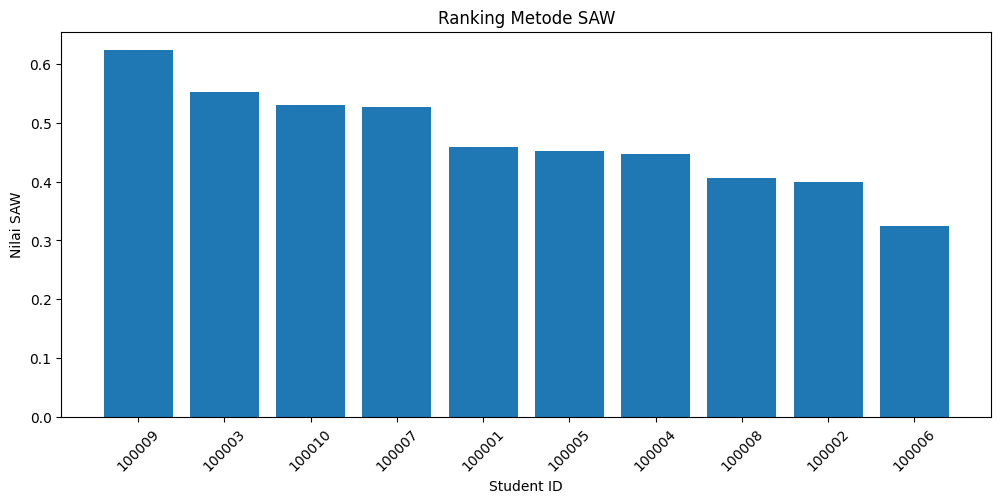

In [ ]:
# =========================================================
# VISUALISASI SAW
# =========================================================

ranking = df_saw.sort_values(
    by='Ranking'
)

plt.figure(figsize=(12,5))

plt.bar(
    ranking['Alternatif'].astype(str),
    ranking['Skor_Akhir']
)

plt.xlabel("Student ID")
plt.ylabel("Nilai SAW")
plt.title("Ranking Metode SAW")

plt.xticks(rotation=45)

plt.show()

#ANALISIS/SUMMARY

In [ ]:
# =========================================================
# ANALISIS HASIL SAW
# =========================================================

print("ANALISIS METODE SAW")
print("="*60)

print("\n1. Akuisisi Data")
print("Dataset diperoleh dari data kualitas tidur dan faktor pendukung lainnya.")
print("Jumlah data:", len(df))
print("Jumlah atribut:", len(df.columns))

print("\n2. Tahap Metode SAW")
print("- Menentukan kriteria dan bobot")
print("- Melakukan normalisasi")
print("- Menghitung nilai preferensi")
print("- Melakukan perangkingan")

print("\n3. Output SAW")
print("5 Ranking Terbaik Berdasarkan SAW")

display(ranking_saw.head())

print("\n4. Analisis Hasil")
print("Alternatif dengan nilai preferensi tertinggi dianggap sebagai alternatif terbaik")
print("karena memiliki performa paling optimal berdasarkan bobot kriteria yang digunakan.")

ANALISIS METODE SAW

1. Akuisisi Data
Dataset diperoleh dari data kualitas tidur dan faktor pendukung lainnya.
Jumlah data: 150000
Jumlah atribut: 20

2. Tahap Metode SAW
- Menentukan kriteria dan bobot
- Melakukan normalisasi
- Menghitung nilai preferensi
- Melakukan perangkingan

3. Output SAW
5 Ranking Terbaik Berdasarkan SAW


,Alternatif,C1 (Stress Level),C2 (Anxiety Score),C3 (Depression Score),C4 (Academic Pressure),C5 (Social Support),C6 (Screen Time),C7 (Sleep Quality),C8 (Daily Sleep Hours),C9 (Coding Hours),C10 (Assignment Deadline),Skor_Akhir,Ranking
8,100009,1,1,1,7,1,1.3,2,5.4,6.410035,8,0.624391,1
2,100003,1,2,7,8,3,1.5,3,4.8,7.587945,2,0.551854,2
9,100010,2,4,2,4,7,11.5,1,7.0,7.372653,1,0.530570,3
6,100007,1,5,9,9,6,7.8,2,8.0,1.522753,8,0.526944,4
0,100001,3,10,3,4,6,6.1,2,6.8,4.370861,3,0.459484,5



4. Analisis Hasil
Alternatif dengan nilai preferensi tertinggi dianggap sebagai alternatif terbaik
karena memiliki performa paling optimal berdasarkan bobot kriteria yang digunakan.


#METODE AHP

In [ ]:
# =========================================================
# METODE AHP
# =========================================================

import numpy as np
import pandas as pd

criteria = [
    'Stress Level',
    'Sleep Quality',
    'Physical Activity',
    'Heart Rate'
]

pairwise_matrix = np.array([
    [1,   3,   5,   7],
    [1/3, 1,   3,   5],
    [1/5, 1/3, 1,   3],
    [1/7, 1/5, 1/3, 1]
])

ahp_df = pd.DataFrame(
    pairwise_matrix,
    columns=criteria,
    index=criteria
)

print("Matriks Perbandingan Berpasangan")
display(ahp_df)

column_sum = pairwise_matrix.sum(axis=0)

normalized_matrix = (
    pairwise_matrix / column_sum
)

normalized_df = pd.DataFrame(
    normalized_matrix,
    columns=criteria,
    index=criteria
)

print("Matrix Normalisasi")
display(normalized_df)

priority_weight = normalized_matrix.mean(axis=1)

bobot_ahp = pd.DataFrame({
    'Kriteria': criteria,
    'Bobot': priority_weight
})

print("Bobot Prioritas AHP")
display(bobot_ahp)

Matriks Perbandingan Berpasangan


,Stress Level,Sleep Quality,Physical Activity,Heart Rate
Stress Level,1.000000,3.000000,5.000000,7.0
Sleep Quality,0.333333,1.000000,3.000000,5.0
Physical Activity,0.200000,0.333333,1.000000,3.0
Heart Rate,0.142857,0.200000,0.333333,1.0


Matrix Normalisasi


,Stress Level,Sleep Quality,Physical Activity,Heart Rate
Stress Level,0.596591,0.661765,0.535714,0.4375
Sleep Quality,0.198864,0.220588,0.321429,0.3125
Physical Activity,0.119318,0.073529,0.107143,0.1875
Heart Rate,0.085227,0.044118,0.035714,0.0625


Bobot Prioritas AHP


,Kriteria,Bobot
0,Stress Level,0.557892
1,Sleep Quality,0.263345
2,Physical Activity,0.121873
3,Heart Rate,0.056890


Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='object')


#CEK NAMA KOLOM

In [ ]:
# =========================================================
# CEK NAMA KOLOM
# =========================================================

print(df_saw.columns.tolist())

['Alternatif', 'C1 (Stress Level)', 'C2 (Anxiety Score)', 'C3 (Depression Score)', 'C4 (Academic Pressure)', 'C5 (Social Support)', 'C6 (Screen Time)', 'C7 (Sleep Quality)', 'C8 (Daily Sleep Hours)', 'C9 (Coding Hours)', 'C10 (Assignment Deadline)', 'Skor_Akhir', 'Ranking']


#METODE TOPSIS

=== HASIL TOPSIS ===


,Alternatif,Nilai Preferensi
7,100008,0.573968
6,100007,0.552875
1,100002,0.530195
0,100001,0.515518
4,100005,0.515037
3,100004,0.500867
5,100006,0.481202
9,100010,0.465841
2,100003,0.396435
8,100009,0.322521


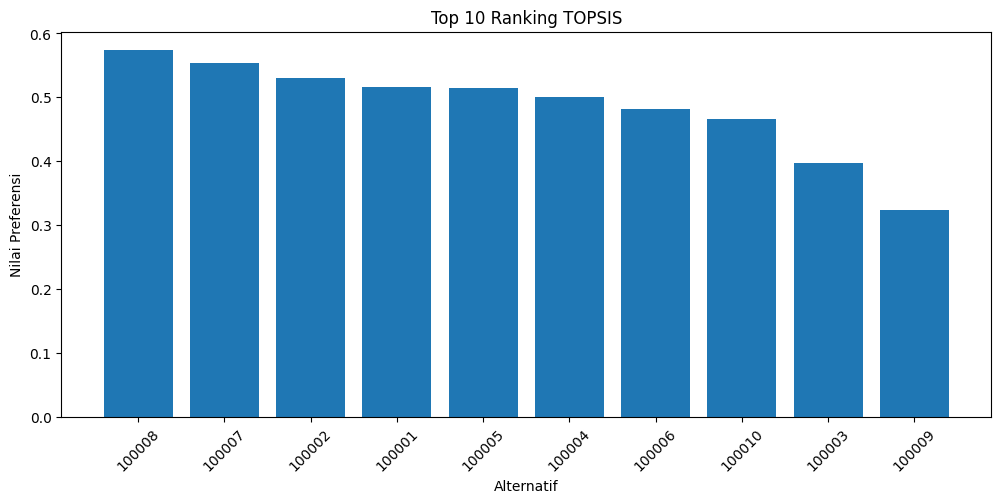

ANALISIS METODE TOPSIS

1. Akuisisi Data
Dataset digunakan untuk proses pengambilan keputusan multikriteria.
Jumlah data: 10
Jumlah atribut: 10

2. Tahap Metode TOPSIS
- Menentukan kriteria dan bobot
- Melakukan normalisasi matriks
- Menghitung normalisasi terbobot
- Menentukan solusi ideal positif dan negatif
- Menghitung jarak solusi ideal
- Menghitung nilai preferensi
- Melakukan perangkingan

3. Output TOPSIS
5 Ranking Terbaik Berdasarkan TOPSIS


,Alternatif,Nilai Preferensi
7,100008,0.573968
6,100007,0.552875
1,100002,0.530195
0,100001,0.515518
4,100005,0.515037



4. Analisis Hasil
Alternatif dengan nilai preferensi tertinggi dianggap sebagai
alternatif terbaik karena memiliki jarak paling dekat
dengan solusi ideal positif.


In [ ]:
# =========================================================
# METODE TOPSIS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# KRITERIA DAN BOBOT
# =========================================================

criteria = [
    'C1 (Stress Level)',
    'C2 (Anxiety Score)',
    'C3 (Depression Score)',
    'C4 (Academic Pressure)',
    'C5 (Social Support)',
    'C6 (Screen Time)',
    'C7 (Sleep Quality)',
    'C8 (Daily Sleep Hours)',
    'C9 (Coding Hours)',
    'C10 (Assignment Deadline)'
]

weights = np.array([
    0.10,
    0.10,
    0.10,
    0.10,
    0.10,
    0.10,
    0.10,
    0.10,
    0.10,
    0.10
])

# =========================================================
# AMBIL DATA KRITERIA
# =========================================================

X = df_saw[criteria].values

# =========================================================
# NORMALISASI MATRIX
# =========================================================

normalisasi = (
    X / np.sqrt((X**2).sum(axis=0))
)

# =========================================================
# NORMALISASI TERBOBOT
# =========================================================

weighted_matrix = (
    normalisasi * weights
)

# =========================================================
# SOLUSI IDEAL POSITIF & NEGATIF
# =========================================================

ideal_positif = weighted_matrix.max(axis=0)
ideal_negatif = weighted_matrix.min(axis=0)

# =========================================================
# JARAK TERHADAP SOLUSI IDEAL
# =========================================================

jarak_positif = np.sqrt(
    ((weighted_matrix - ideal_positif)**2).sum(axis=1)
)

jarak_negatif = np.sqrt(
    ((weighted_matrix - ideal_negatif)**2).sum(axis=1)
)

# =========================================================
# NILAI PREFERENSI
# =========================================================

preferensi = (
    jarak_negatif /
    (jarak_positif + jarak_negatif)
)

# =========================================================
# HASIL TOPSIS
# =========================================================

hasil_topsis = pd.DataFrame({
    'Alternatif': df_saw['Alternatif'],
    'Nilai Preferensi': preferensi
})

hasil_topsis = hasil_topsis.sort_values(
    by='Nilai Preferensi',
    ascending=False
)

print("=== HASIL TOPSIS ===")

display(hasil_topsis.head(10))

# =========================================================
# VISUALISASI TOPSIS
# =========================================================

top_topsis = hasil_topsis.head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top_topsis['Alternatif'].astype(str),
    top_topsis['Nilai Preferensi']
)

plt.title('Top 10 Ranking TOPSIS')
plt.xlabel('Alternatif')
plt.ylabel('Nilai Preferensi')

plt.xticks(rotation=45)

plt.show()

# =========================================================
# ANALISIS HASIL TOPSIS
# =========================================================

print("ANALISIS METODE TOPSIS")
print("="*60)

print("\n1. Akuisisi Data")
print("Dataset digunakan untuk proses pengambilan keputusan multikriteria.")
print("Jumlah data:", len(df_saw))
print("Jumlah atribut:", len(criteria))

print("\n2. Tahap Metode TOPSIS")
print("- Menentukan kriteria dan bobot")
print("- Melakukan normalisasi matriks")
print("- Menghitung normalisasi terbobot")
print("- Menentukan solusi ideal positif dan negatif")
print("- Menghitung jarak solusi ideal")
print("- Menghitung nilai preferensi")
print("- Melakukan perangkingan")

print("\n3. Output TOPSIS")
print("5 Ranking Terbaik Berdasarkan TOPSIS")

display(hasil_topsis.head())

print("\n4. Analisis Hasil")
print("Alternatif dengan nilai preferensi tertinggi dianggap sebagai")
print("alternatif terbaik karena memiliki jarak paling dekat")
print("dengan solusi ideal positif.")